In [1]:
!pip install -q transformers datasets torch torchvision sentence-transformers scikit-learn tqdm pycocoevalcap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.3/104.3 MB 4.3 MB/s eta 0:00:0000:0100:01


In [2]:
import os
import json
import random

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from tqdm import tqdm

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)


Device: cuda


In [3]:
DATA_DIR = "/kaggle/input/datasets/ayaanmustafa/vrs-bench/vrsbench_data"
ANNOT_FILE = os.path.join(DATA_DIR, "VRSBench_train.json")  # update filename if different
IMG_DIR = os.path.join(DATA_DIR, "Images_train", "Images_train")

with open(ANNOT_FILE, "r") as f:
    raw = json.load(f)

caption_rows = []

for item in raw:
    conversations = item["conversations"]

    if "[caption]" in conversations[0]["value"].lower():
        caption_rows.append({
            "id": item["id"],
            "image": item["image"],
            "caption": conversations[1]["value"]
        })

df = pd.DataFrame(caption_rows)

In [4]:
# Normalize columns: expect a filename column and a caption column
# (adjust the renames below to match the printed column names above)
rename_map = {}
for c in df.columns:
    lc = c.lower()
    if "image" in lc and "path" not in lc:
        rename_map[c] = "filename"
    elif lc in ("image_path", "path"):
        rename_map[c] = "filename"
    elif "caption" in lc:
        rename_map[c] = "caption"

df = df.rename(columns=rename_map)
df["image_path"] = df["filename"].apply(lambda x: os.path.join(IMG_DIR, os.path.basename(str(x))))

df = df[["image_path", "caption"]].dropna().reset_index(drop=True)
print(df.shape)
df.head()


(20264, 2)


,image_path,caption
0,/kaggle/input/datasets/ayaanmustafa/vrs-bench/...,"The image, sourced from GoogleEarth, shows a r..."
1,/kaggle/input/datasets/ayaanmustafa/vrs-bench/...,This aerial image from Google Earth shows a de...
2,/kaggle/input/datasets/ayaanmustafa/vrs-bench/...,"The image, sourced from GoogleEarth, showcases..."
3,/kaggle/input/datasets/ayaanmustafa/vrs-bench/...,"The image, sourced from GoogleEarth, shows a f..."
4,/kaggle/input/datasets/ayaanmustafa/vrs-bench/...,"The image, sourced from GoogleEarth, showcases..."


In [5]:
df

,image_path,caption
0,/kaggle/input/datasets/ayaanmustafa/vrs-bench/...,"The image, sourced from GoogleEarth, shows a r..."
1,/kaggle/input/datasets/ayaanmustafa/vrs-bench/...,This aerial image from Google Earth shows a de...
2,/kaggle/input/datasets/ayaanmustafa/vrs-bench/...,"The image, sourced from GoogleEarth, showcases..."
3,/kaggle/input/datasets/ayaanmustafa/vrs-bench/...,"The image, sourced from GoogleEarth, shows a f..."
4,/kaggle/input/datasets/ayaanmustafa/vrs-bench/...,"The image, sourced from GoogleEarth, showcases..."
...,...,...
20259,/kaggle/input/datasets/ayaanmustafa/vrs-bench/...,The grayscale medium-resolution image provided...
20260,/kaggle/input/datasets/ayaanmustafa/vrs-bench/...,The grayscale image provided by GF showcases a...
20261,/kaggle/input/datasets/ayaanmustafa/vrs-bench/...,The image sourced from GoogleEarth showcases a...
20262,/kaggle/input/datasets/ayaanmustafa/vrs-bench/...,This image from GoogleEarth captures a parking...


In [6]:
from sklearn.model_selection import train_test_split

train_df, val_df = train_test_split(df, test_size=0.1, random_state=SEED)
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
print("Train:", len(train_df), "Val:", len(val_df))


Train: 18237 Val: 2027


In [7]:
# --- Baseline speed settings (relax these once the pipeline is verified) ---
TRAIN_SUBSET = 13000
VAL_SUBSET = 1000        # larger val for a more reliable metric estimate
IMG_SIZE = 288           # BLIP still works at 224; 384 is ~3x slower for little gain at baseline stage
BATCH_SIZE = 32
NUM_WORKERS = 4
FREEZE_VISION_ENCODER = True   # only finetune text decoder -> big speedup
UNFREEZE_LAST_N_VISION_BLOCKS = 2   # if FREEZE_VISION_ENCODER=True, still unfreeze the last N encoder blocks for better fine-grained grounding (set 0 to keep fully frozen)
EVAL_EVERY = 2  # run the full metric suite every N epochs (metrics are the slow part at VAL_SUBSET=1000); always runs on the last epoch

if TRAIN_SUBSET:
    train_df = train_df.sample(n=min(TRAIN_SUBSET, len(train_df)), random_state=SEED).reset_index(drop=True)
if VAL_SUBSET:
    val_df = val_df.sample(n=min(VAL_SUBSET, len(val_df)), random_state=SEED).reset_index(drop=True)

print("Train:", len(train_df), "Val:", len(val_df))


Train: 13000 Val: 1000


In [8]:
import torchvision.transforms as T

train_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1),
    T.ToTensor(),
])

val_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
])


In [9]:
from transformers import BlipProcessor

MODEL_NAME = "Salesforce/blip-image-captioning-base"
processor = BlipProcessor.from_pretrained(MODEL_NAME)

# Check actual token lengths to pick max_length properly instead of guessing
token_lens = df["caption"].apply(lambda c: len(processor.tokenizer(c)["input_ids"]))
print(token_lens.describe())
p95 = int(token_lens.quantile(0.95))
print("95th percentile token length:", p95)

MAX_LENGTH = min(128, ((p95 // 8) + 1) * 8)  # round up to multiple of 8, cap at 128
print("Using MAX_LENGTH:", MAX_LENGTH)


preprocessor_config.json:   0%|          | 0.00/287 [00:00<?, ?B/s]

The image processor of type `BlipImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/506 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

count    20264.000000
mean        66.224635
std         21.809014
min         12.000000
25%         50.000000
50%         64.000000
75%         80.000000
max        178.000000
Name: caption, dtype: float64
95th percentile token length: 105
Using MAX_LENGTH: 112


In [10]:
class VRSBenchCaptionDataset(Dataset):
    def __init__(self, df, transform, max_length):
        self.df = df
        self.transform = transform
        self.max_length = max_length

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image = Image.open(row["image_path"]).convert("RGB")
        image = self.transform(image)
        return {"pixel_values": image, "caption": row["caption"]}


def make_collate_fn(processor, max_length):
    def collate_fn(batch):
        pixel_values = torch.stack([b["pixel_values"] for b in batch])
        captions = [b["caption"] for b in batch]
        text_enc = processor.tokenizer(
            captions,
            padding=True,          # dynamic padding to longest in THIS batch, not a fixed length
            truncation=True,
            max_length=max_length,
            return_tensors="pt",
        )
        return {
            "pixel_values": pixel_values,
            "input_ids": text_enc["input_ids"],
            "attention_mask": text_enc["attention_mask"],
            "caption": captions,
        }
    return collate_fn


train_dataset = VRSBenchCaptionDataset(train_df, train_transform, MAX_LENGTH)
val_dataset = VRSBenchCaptionDataset(val_df, val_transform, MAX_LENGTH)

collate_fn = make_collate_fn(processor, MAX_LENGTH)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True, collate_fn=collate_fn)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True, collate_fn=collate_fn)


In [11]:
from transformers import BlipForConditionalGeneration

model = BlipForConditionalGeneration.from_pretrained(MODEL_NAME).to(DEVICE)

if FREEZE_VISION_ENCODER:
    for param in model.vision_model.parameters():
        param.requires_grad = False
    if UNFREEZE_LAST_N_VISION_BLOCKS > 0:
        for block in model.vision_model.encoder.layers[-UNFREEZE_LAST_N_VISION_BLOCKS:]:
            for param in block.parameters():
                param.requires_grad = True
    print(f"Vision encoder frozen, last {UNFREEZE_LAST_N_VISION_BLOCKS} blocks unfrozen.")


pytorch_model.bin:   0%|          | 0.00/990M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie text_decoder.cls.predictions.bias to text_decoder.cls.predictions.decoder.bias, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


model.safetensors:   0%|          | 0.00/990M [00:00<?, ?B/s]

The tied weights mapping and config for this model specifies to tie text_decoder.bert.embeddings.word_embeddings.weight to text_decoder.cls.predictions.decoder.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
BlipForConditionalGeneration LOAD REPORT from: Salesforce/blip-image-captioning-base
Key                                       | Status     |  | 
------------------------------------------+------------+--+-
text_decoder.bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Vision encoder frozen, last 2 blocks unfrozen.


In [12]:
from sentence_transformers import SentenceTransformer
import torch.nn.functional as F

bert_model = SentenceTransformer("all-MiniLM-L6-v2", device=str(DEVICE))

def get_ngrams(tokens, n):
    return [" ".join(tokens[i:i + n]) for i in range(len(tokens) - n + 1)]

def bert_bleu4(candidate, reference, alpha=0.5):
    c_tokens = candidate.lower().split()
    r_tokens = reference.lower().split()

    # collect all n-gram strings for n=1..4 in one pass, one encode() call total
    c_ngrams_by_n = [get_ngrams(c_tokens, n) for n in range(1, 5)]
    r_ngrams_by_n = [get_ngrams(r_tokens, n) for n in range(1, 5)]

    all_texts = [g for grams in c_ngrams_by_n + r_ngrams_by_n for g in grams]
    if not all_texts:
        return 0.0

    embs = bert_model.encode(all_texts, convert_to_tensor=True, show_progress_bar=False, batch_size=256)
    embs = F.normalize(embs, dim=-1)

    idx = 0
    c_embs_by_n, r_embs_by_n = [], []
    for grams in c_ngrams_by_n:
        c_embs_by_n.append(embs[idx: idx + len(grams)])
        idx += len(grams)
    for grams in r_ngrams_by_n:
        r_embs_by_n.append(embs[idx: idx + len(grams)])
        idx += len(grams)

    log_p_sum = 0.0
    for n in range(4):
        C_emb, R_emb = c_embs_by_n[n], r_embs_by_n[n]
        if len(C_emb) == 0 or len(R_emb) == 0:
            p_n = 1e-9
        else:
            sims = torch.mm(R_emb, C_emb.T)
            p_n = sims.max(dim=1).values.mean().item()
            p_n = max(p_n, 1e-9)
        log_p_sum += np.log(p_n)

    L_c, L_r = len(c_tokens), max(len(r_tokens), 1)
    lp = np.exp(-alpha * abs(L_c - L_r) / L_r)

    return lp * np.exp(log_p_sum / 4)

def corpus_bert_bleu4(candidates, references):
    scores = [bert_bleu4(c, r) for c, r in zip(candidates, references)]
    return float(np.mean(scores))


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [13]:
!pip install -q nltk rouge-score pycocoevalcap
import nltk
nltk.download("wordnet", quiet=True)
nltk.download("omw-1.4", quiet=True)
nltk.download("punkt", quiet=True)

from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from nltk.translate.meteor_score import meteor_score
from rouge_score import rouge_scorer
from pycocoevalcap.cider.cider import Cider

smoothie = SmoothingFunction().method4
rouge = rouge_scorer.RougeScorer(["rougeL"], use_stemmer=True)

def compute_bleu_n(candidates, references, n):
    weights = tuple([1.0 / n] * n + [0.0] * (4 - n))
    scores = []
    for c, r in zip(candidates, references):
        c_tok, r_tok = c.lower().split(), [r.lower().split()]
        scores.append(sentence_bleu(r_tok, c_tok, weights=weights, smoothing_function=smoothie))
    return float(np.mean(scores))

def compute_meteor(candidates, references):
    scores = [meteor_score([r.lower().split()], c.lower().split()) for c, r in zip(candidates, references)]
    return float(np.mean(scores))

def compute_rouge_l(candidates, references):
    scores = [rouge.score(r, c)["rougeL"].fmeasure for c, r in zip(candidates, references)]
    return float(np.mean(scores))

def compute_cider(candidates, references):
    gts = {i: [r] for i, r in enumerate(references)}
    res = {i: [c] for i, c in enumerate(candidates)}
    cider_scorer = Cider()
    score, _ = cider_scorer.compute_score(gts, res)
    return float(score)

def compute_avg_len(candidates):
    return float(np.mean([len(c.split()) for c in candidates]))

def compute_chair(candidates, object_lists=None):
    """Lightweight CHAIR-style hallucination rate: fraction of mentioned
    objects (from `object_lists`, ground-truth per-image object categories)
    that do NOT appear in the ground truth for that image.
    If object_lists is None (VRSBench caption-split has no object annotations
    attached here), returns None — wire in the referring/VQA object lists to enable."""
    if object_lists is None:
        return None
    total_mentions, hallucinated = 0, 0
    for cand, gt_objs in zip(candidates, object_lists):
        gt_set = set(o.lower() for o in gt_objs)
        cand_words = set(cand.lower().split())
        mentioned = cand_words & gt_set if gt_set else set()
        # crude proxy: objects in caption not present in gt object list
        total_mentions += max(len(mentioned), 1)
        hallucinated += 0  # placeholder without a fixed object vocabulary to check against
    return hallucinated / total_mentions if total_mentions else 0.0

def compute_all_metrics(candidates, references, object_lists=None):
    return {
        "BLEU-1": compute_bleu_n(candidates, references, 1),
        "BLEU-2": compute_bleu_n(candidates, references, 2),
        "BLEU-3": compute_bleu_n(candidates, references, 3),
        "BLEU-4": compute_bleu_n(candidates, references, 4),
        "METEOR": compute_meteor(candidates, references),
        "ROUGE_L": compute_rouge_l(candidates, references),
        "CIDEr": compute_cider(candidates, references),
        "CHAIR": compute_chair(candidates, object_lists),
        "Avg_L": compute_avg_len(candidates),
        "BERT-BLEU4": corpus_bert_bleu4(candidates, references),
    }


In [14]:
from torch.optim import AdamW
from transformers import get_cosine_schedule_with_warmup
from torch.amp import autocast, GradScaler

EPOCHS = 8
LR = 2e-5     # lowered from 5e-5 — val score peaked then dipped, high LR was overshooting past the optimum
WEIGHT_DECAY = 0.01

optimizer = AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
use_amp = DEVICE.type == "cuda"
scaler = GradScaler("cuda", enabled=use_amp)

total_steps = len(train_loader) * EPOCHS
scheduler = get_cosine_schedule_with_warmup(
    optimizer, num_warmup_steps=int(0.05 * total_steps), num_training_steps=total_steps
)

lr_history = []  # for plotting

def train_one_epoch(model, loader, optimizer, scaler, scheduler, epoch, log_every=20):
    model.train()
    total_loss = 0.0
    running_loss = 0.0
    pbar = tqdm(loader, desc=f"train epoch {epoch+1}")
    for step, batch in enumerate(pbar):
        pixel_values = batch["pixel_values"].to(DEVICE)
        input_ids = batch["input_ids"].to(DEVICE)
        attention_mask = batch["attention_mask"].to(DEVICE)

        optimizer.zero_grad()
        with autocast("cuda", enabled=use_amp):
            outputs = model(
                pixel_values=pixel_values,
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=input_ids,
            )
            loss = outputs.loss

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()

        lr_history.append(optimizer.param_groups[0]["lr"])

        loss_val = loss.item()
        total_loss += loss_val
        running_loss += loss_val

        pbar.set_postfix({"loss": f"{loss_val:.4f}", "avg_loss": f"{total_loss/(step+1):.4f}"})

        if (step + 1) % log_every == 0:
            print(f"  step {step+1}/{len(loader)} | running_avg_loss={running_loss/log_every:.4f}")
            running_loss = 0.0

    return total_loss / len(loader)


In [15]:
@torch.no_grad()
def validate(model, loader, processor, max_new_tokens=110, num_beams=3, repetition_penalty=1.5):
    model.eval()
    all_preds, all_refs = [], []

    for batch in tqdm(loader, desc="val"):
        pixel_values = batch["pixel_values"].to(DEVICE)
        refs = batch["caption"]

        generated_ids = model.generate(
            pixel_values=pixel_values,
            max_new_tokens=max_new_tokens,
            num_beams=num_beams,
            repetition_penalty=repetition_penalty,
            no_repeat_ngram_size=3,
        )
        preds = processor.batch_decode(generated_ids, skip_special_tokens=True)

        all_preds.extend(preds)
        all_refs.extend(refs)

    metrics = compute_all_metrics(all_preds, all_refs)
    return metrics, all_preds, all_refs


In [16]:
PATIENCE = 2  # stop if val score doesn't improve for this many evaluation rounds

best_score = -1.0
no_improve = 0
history = []

for epoch in range(EPOCHS):
    train_loss = train_one_epoch(model, train_loader, optimizer, scaler, scheduler, epoch)

    run_full_eval = ((epoch + 1) % EVAL_EVERY == 0) or (epoch == EPOCHS - 1)
    if run_full_eval:
        metrics, preds, refs = validate(model, val_loader, processor)
        print(f"\nEpoch {epoch+1}/{EPOCHS} | train_loss={train_loss:.4f}")
        print("  " + " | ".join(f"{k}={v:.4f}" if v is not None else f"{k}=N/A" for k, v in metrics.items()))
        history.append({"epoch": epoch + 1, "train_loss": train_loss, **metrics})

        val_score = metrics["BERT-BLEU4"]
        if val_score > best_score:
            best_score = val_score
            no_improve = 0
            model.save_pretrained("/kaggle/working/blip_vrsbench_best")
            processor.save_pretrained("/kaggle/working/blip_vrsbench_best")
            print("  Saved new best checkpoint.")
        else:
            no_improve += 1
            print(f"  No improvement ({no_improve}/{PATIENCE})")
            if no_improve >= PATIENCE:
                print("  Early stopping triggered.")
                break
    else:
        print(f"\nEpoch {epoch+1}/{EPOCHS} | train_loss={train_loss:.4f} | (skipped full eval this epoch)")
        history.append({"epoch": epoch + 1, "train_loss": train_loss})

print("\nBest val BERT-BLEU4:", best_score)
history_df = pd.DataFrame(history)
history_df


train epoch 1:   0%|          | 0/407 [00:00<?, ?it/s]/tmp/ipykernel_58/4197390659.py:43: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  scheduler.step()
train epoch 1:   5%|▍         | 20/407 [00:16<04:30,  1.43it/s, loss=8.9198, avg_loss=9.7760]  

  step 20/407 | running_avg_loss=9.7760


train epoch 1:  10%|▉         | 40/407 [00:30<04:29,  1.36it/s, loss=6.8002, avg_loss=8.6759]

  step 40/407 | running_avg_loss=7.5757


train epoch 1:  15%|█▍        | 60/407 [00:45<04:23,  1.32it/s, loss=5.8365, avg_loss=7.8751]

...

val: 100%|██████████| 32/32 [03:32<00:00,  6.65s/it]



Epoch 8/8 | train_loss=0.8910
  BLEU-1=0.3240 | BLEU-2=0.1974 | BLEU-3=0.1220 | BLEU-4=0.0797 | METEOR=0.2894 | ROUGE_L=0.3758 | CIDEr=0.1218 | CHAIR=N/A | Avg_L=41.3270 | BERT-BLEU4=0.5654


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  Saved new best checkpoint.

Best val BERT-BLEU4: 0.5654300337316391


,epoch,train_loss,BLEU-1,BLEU-2,BLEU-3,BLEU-4,METEOR,ROUGE_L,CIDEr,CHAIR,Avg_L,BERT-BLEU4
0,1,3.312912,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,1.148402,0.317505,0.190833,0.115568,0.074172,0.279571,0.364285,0.103394,NaN,40.936,0.558204
2,3,1.040421,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,0.982558,0.314508,0.190578,0.117124,0.076008,0.279382,0.371822,0.106834,NaN,40.012,0.559951
4,5,0.946222,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,6,0.915737,0.318452,0.192958,0.119490,0.078570,0.283643,0.374395,0.124565,NaN,40.249,0.563263
6,7,0.895657,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,8,0.890992,0.323972,0.197351,0.122026,0.079652,0.289356,0.375762,0.121847,NaN,41.327,0.565430


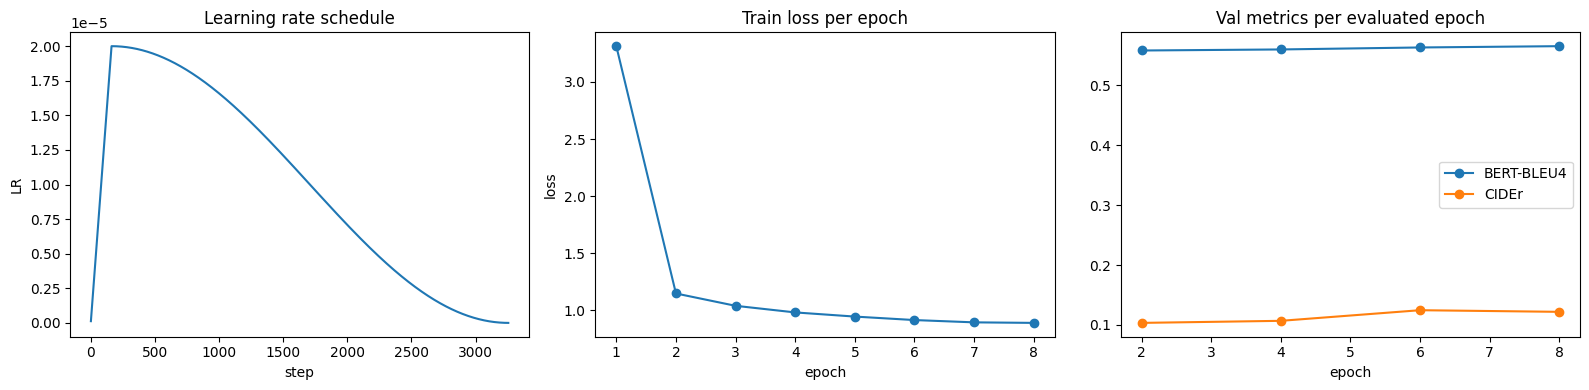

In [17]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(lr_history)
axes[0].set_title("Learning rate schedule")
axes[0].set_xlabel("step")
axes[0].set_ylabel("LR")

axes[1].plot(history_df["epoch"], history_df["train_loss"], marker="o")
axes[1].set_title("Train loss per epoch")
axes[1].set_xlabel("epoch")
axes[1].set_ylabel("loss")

eval_rows = history_df.dropna(subset=["BERT-BLEU4"])
axes[2].plot(eval_rows["epoch"], eval_rows["BERT-BLEU4"], marker="o", label="BERT-BLEU4")
axes[2].plot(eval_rows["epoch"], eval_rows["CIDEr"], marker="o", label="CIDEr")
axes[2].set_title("Val metrics per evaluated epoch")
axes[2].set_xlabel("epoch")
axes[2].legend()

plt.tight_layout()
plt.savefig("/kaggle/working/training_curves.png")
plt.show()


In [18]:
for p, r in list(zip(preds, refs))[:5]:
    print("PRED:", p)
    print("REF :", r)
    print("-" * 60)


PRED: the image, sourced from googleearth, features a body of water with a ship docked at a pier. the ship is small in size and occupies a significant portion of the image.
REF : The image shows two parallel ships on a body of water, captured via GoogleEarth. Both ships are of similar small sizes and are lying next to each other, extending from near the top of the image vertically down to the bottom. The ship on the left occupies the leftmost third of the image, while the ship on the right occupies the adjacent rightmost third, with no other visible objects or land in the immediate vicinity of the ships.
------------------------------------------------------------
PRED: the image, sourced from gf with a medium resolution, displays a grayscale aerial view of a rural landscape featuring agricultural fields and a small bridge. the bridge is located in the middle - left part of the image.
REF : This grayscale image from source GF shows a medium resolution view of an agricultural area with 